# Molecular Docking Graph Search Experiment

This notebook uses the SDK local application APIs to demonstrate molecular-docking graph search. GBS samples provide candidate subgraphs, followed by clique shrinking and classical search.

## 1. Initialize the environment

In [1]:
import numpy as np

from jiuzhang.local.applications import (
    clique_search,
    clique_shrink,
    draw_graph,
    is_clique,
    load_phat_graph,
    load_tace_as_graph,
    postselect_subgraphs,
    subgraph_density_summary,
)

import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Sarasa UI SC', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

## 2. Load the TACE-AS graph

TACE-AS (24, 24)


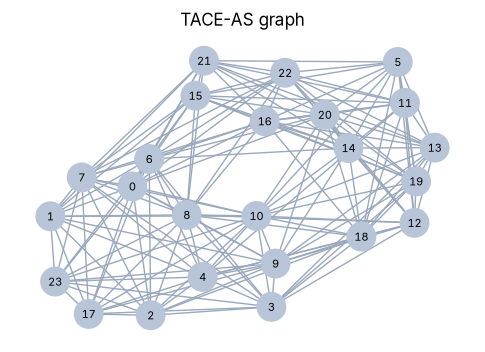

In [2]:
tace_as = load_tace_as_graph()
print(tace_as.name, tace_as.adjacency.shape)

draw_graph(tace_as.adjacency, title='TACE-AS graph')
plt.show()

## 3. Postselect samples and compare graph density

`min_photons` and `max_photons` define the allowed total-count range. Each retained sample is converted into a candidate node set.

In [3]:
candidate_subgraphs = postselect_subgraphs(tace_as, min_photons=8, max_photons=8)
summary = subgraph_density_summary(tace_as.adjacency, candidate_subgraphs, seed=7)

print('Candidate count:', len(candidate_subgraphs))
print('Sampled mean density: {:.4f}'.format(summary['sampled_mean_density']))
print('Uniform mean density: {:.4f}'.format(summary['uniform_mean_density']))

Candidate count: 1984
Sampled mean density: 0.7005
Uniform mean density: 0.5849


## 4. Search for clique structures

First candidate is clique: True
First ten clique sizes: [8, 8, 8, 8, 8, 8, 8, 8, 8, 8]
Best clique size: 8
Best clique nodes: [5, 10, 12, 13, 14, 18, 19, 20]


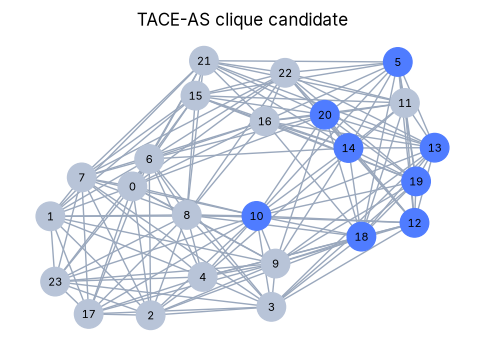

In [4]:
shrunk = [clique_shrink(tace_as.adjacency, nodes) for nodes in candidate_subgraphs[:50]]
searched = [clique_search(tace_as.adjacency, nodes, iterations=10) for nodes in shrunk]
clique_sizes = [len(nodes) for nodes in searched]
first_clique = searched[int(np.argmax(clique_sizes))]

print('First candidate is clique:', is_clique(tace_as.adjacency, first_clique))
print('First ten clique sizes:', clique_sizes[:10])
print('Best clique size:', max(clique_sizes))
print('Best clique nodes:', first_clique)

draw_graph(tace_as.adjacency, first_clique, title='TACE-AS clique candidate')
plt.show()

## 5. Search example on the PHat graph

Largest clique found: [19, 47, 53, 123, 204, 267, 270, 299]
Largest clique size: 8


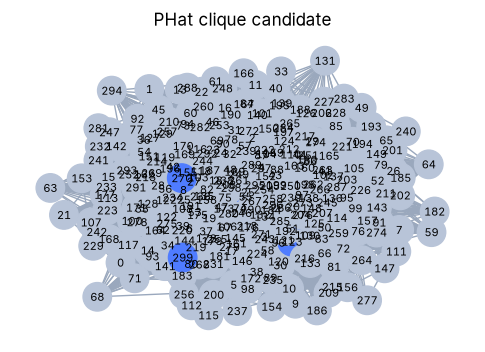

In [5]:
phat = load_phat_graph()
phat_subgraphs = postselect_subgraphs(phat, min_photons=16, max_photons=20)
phat_shrunk = [clique_shrink(phat.adjacency, nodes) for nodes in phat_subgraphs[:100]]
phat_searched = [clique_search(phat.adjacency, nodes, iterations=10) for nodes in phat_shrunk]
phat_sizes = [len(nodes) for nodes in phat_searched]
largest_clique = phat_searched[int(np.argmax(phat_sizes))]

print('Largest clique found:', largest_clique)
print('Largest clique size:', len(largest_clique))

draw_graph(phat.adjacency, largest_clique, title='PHat clique candidate')
plt.show()